<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module3_Lab3_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — KNN for Image Classification (Lab)
**Computer Vision · Machine Learning for Vision**

Uses scikit-learn's built-in **digits** dataset (8×8 grayscale images of handwritten digits) — the same idea as classifying cats vs dogs, but it runs instantly with no download. We build k-NN **from scratch** (L2 distance) *and* use scikit-learn, then tune `k`.

## 1. Load the image dataset

images: (1797, 8, 8) | labels: (1797,)


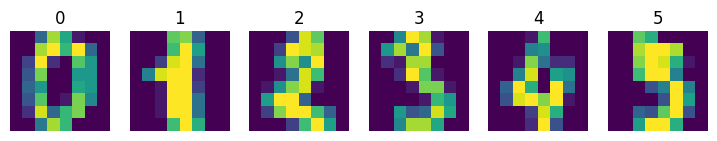

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

digits = load_digits()
print("images:", digits.images.shape, "| labels:", digits.target.shape)
fig, axs = plt.subplots(1, 6, figsize=(9, 2))
for ax, im, lab in zip(axs, digits.images, digits.target):
    ax.imshow(im)
    # ax.imshow(im, cmap="gray")
    ax.set_title(int(lab))
    ax.axis("off")
plt.show()

## 2. Flatten, scale, and split (train / val / test)
Each 8×8 image becomes a 64-length feature vector; pixel values (0–16) are scaled to [0, 1].

In [2]:
print('Min pixel value:', digits.images.min())
print('Max pixel value:', digits.images.max())

Min pixel value: 0.0
Max pixel value: 16.0


In [3]:
X = digits.data / 16.0
y = digits.target
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (1257, 64) | val: (270, 64) | test: (270, 64)


## 3. k-NN from scratch (L2 distance)
k-NN just *memorizes* the training set. Distances use the identity `||a−b||² = ||a||² + ||b||² − 2·a·b` (fully vectorized).

In [4]:
class KNearestNeighbor:
    """A simple k-NN classifier with L2 (Euclidean) distance."""
    def train(self, X, y):
        self.X_train, self.y_train = X, y            # memorize

    def compute_distances(self, X):
        d2 = ((X**2).sum(1, keepdims=True)
              + (self.X_train**2).sum(1)
              - 2 * X.dot(self.X_train.T))
        return np.sqrt(np.maximum(d2, 0))            # clip tiny negatives before sqrt

    def predict(self, X, k=1):
        dists = self.compute_distances(X)
        y_pred = np.empty(dists.shape[0], dtype=int)
        for i in range(dists.shape[0]):
            nearest = self.y_train[np.argsort(dists[i])[:k]]   # k closest labels
            y_pred[i] = np.bincount(nearest).argmax()          # majority vote
        return y_pred

## 4. Evaluate the from-scratch classifier (k = 1)

In [5]:
knn = KNearestNeighbor(); knn.train(X_train, y_train)
pred = knn.predict(X_val, k=1)
print("val accuracy (from-scratch, k=1): %.4f" % (pred == y_val).mean())

val accuracy (from-scratch, k=1): 0.9778


## 5. Choose the best k on the validation set

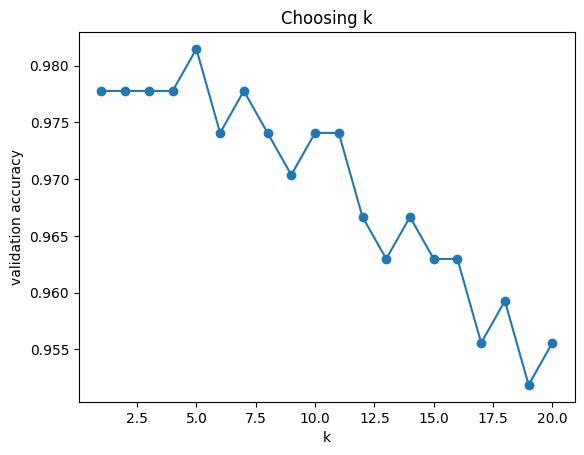

best k = 5 | val accuracy = 0.9815


In [6]:
ks = list(range(1, 21)); accs = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    accs.append(m.score(X_val, y_val))
best_k = ks[int(np.argmax(accs))]
plt.plot(ks, accs, marker="o"); plt.xlabel("k"); plt.ylabel("validation accuracy")
plt.title("Choosing k"); plt.show()
print("best k =", best_k, "| val accuracy = %.4f" % max(accs))

## 6. Test accuracy at the best k (sklearn vs. from-scratch)

In [7]:
sk = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
print("sklearn     test accuracy: %.4f" % sk.score(X_test, y_test))
pred = knn.predict(X_test, k=best_k)
print("from-scratch test accuracy: %.4f" % (pred == y_test).mean())

sklearn     test accuracy: 0.9926
from-scratch test accuracy: 0.9926


## 7. Predict a single image

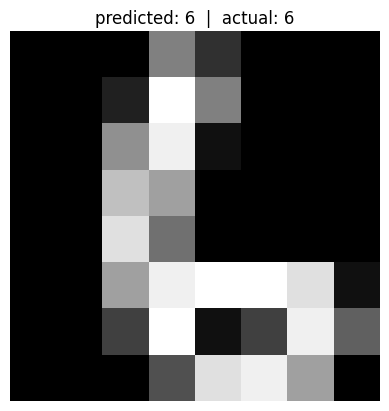

In [8]:
i = 0
sample = X_test[i:i+1]
p = knn.predict(sample, k=best_k)[0]
plt.imshow(sample.reshape(8, 8), cmap="gray")
plt.title(f"predicted: {p}  |  actual: {y_test[i]}"); plt.axis("off"); plt.show()